Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


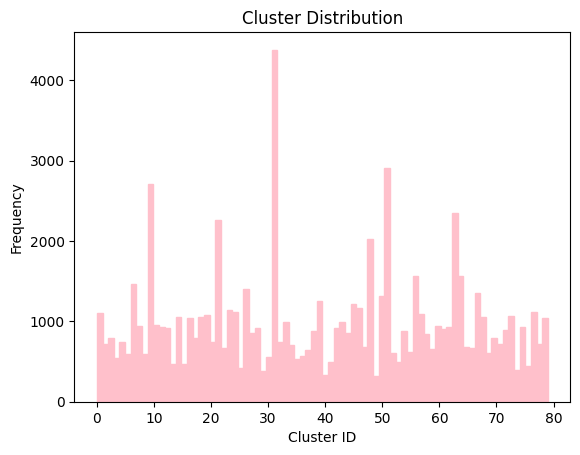

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/ECE5242Proj2-train'

gesture_seqs = {
    "circle": [],
    "beat3": [],
    "beat4": [],
    "eight": [],
    "wave": [],
    "inf": [],
}

def gesture_from_name(fname: str) -> str:
    if fname.startswith("circle"): return "circle"
    if fname.startswith("beat3"):  return "beat3"
    if fname.startswith("beat4"):  return "beat4"
    if fname.startswith("eight"):  return "eight"
    if fname.startswith("wave"):   return "wave"
    return "inf"

for fname in sorted(os.listdir(folder_path)):
    fullpath = os.path.join(folder_path, fname)
    if os.path.isfile(fullpath) and fname.endswith(".txt"):
        data = np.loadtxt(fullpath)
        g = gesture_from_name(fname)
        gesture_seqs[g].append(data)
#print(gesture_seqs['circle'][4])
#Stack all sequences' feature rows for KMeans fitting
X_all_list = []
temp = []
for g in gesture_seqs:
    for seq in gesture_seqs[g]:
        X = seq[:, 1:] # get rid of first column (time)
        temp.append([g, len(X)])
        X_all_list.append(X)

X_all = np.vstack(X_all_list)

#print(temp)
k = 80
kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
labels = kmeans.fit_predict(X_all)


plt.hist(labels, bins=k, color='pink', edgecolor='pink')
plt.xlabel('Cluster ID')
plt.ylabel('Frequency')
plt.title('Cluster Distribution')
plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt



#create dictionary of gesture_discreteobservations (discrete observations)

gesture_observations = {}
for g in gesture_seqs:
    gesture_observations[g] = []
print(temp) #temp keeps track of length of each file, therefore #obsesrvation per global gesture
idx = 0
for (g, T) in temp:
    gesture_observations[g].append(labels[idx:idx+T])
    idx += T

#initialization strategies
def init_pi_left_to_right(N):
    pi = np.zeros(N, dtype=float)
    pi[0] = 1.0
    return pi


def init_A_left_to_right(N, p_stay):
    A = np.zeros((N, N), dtype=float)
    for i in range(N - 1):
        A[i, i] = p_stay
        A[i, i + 1] = 1.0 - p_stay
    A[N - 1, N - 1] = 1.0
    return A

def init_A_strategy_2(seqs, N): # equal time binning

    counts = np.zeros((N, N), dtype=float)

    for z in seqs:
        T = len(z)
        states = (np.floor(np.arange(T) * N / T)).astype(int)
        states = np.clip(states, 0, N-1)

        for t in range(T-1):
            counts[states[t], states[t+1]] += 1.0
    #normalize to get probability
    A = counts / counts.sum(axis=1, keepdims=True)
    return A



def init_B(M ,N, seqs):
  B_temp = np.zeros((N,M), dtype=float)

  for seq in seqs:
    T = len(seq)
    states = (np.floor(np.arange(T) * N / T)).astype(int)
    states = np.clip(states, 0, N-1)

    for t in range(T):
      B_temp[states[t], seq[t]] += 1.0
    #normalize again
    B = B_temp/ B_temp.sum(axis=1, keepdims=True)

  return B


#print(pi, A, B)

#------------------------------- functions used in baulm -welch --------------------------------------------

def forward(obs, A, B, pi, eps=1e-300):
    obs = np.asarray(obs, dtype=int)
    N = A.shape[0]
    T = len(obs)

    alpha = np.zeros((N, T), dtype=float)
    c = np.zeros(T, dtype=float) #scaling factor to prevent underflow

    # init
    alpha[:, 0] = pi * B[:, obs[0]]
    c[0] = 1.0 / max(alpha[:, 0].sum(), eps)
    alpha[:, 0] *= c[0] #rescaling the first column

    # recursion
    for t in range(1, T):
        alpha[:, t] = np.dot(alpha[:, t-1], A) * B[:, obs[t]]
        c[t] = 1.0 / max(alpha[:, t].sum(), eps) #prevent division by 0 in case alpha[:, t].sum() ==0
        alpha[:, t] *= c[t] #rescaling every other column

    loglik = -np.sum(np.log(c + eps)) # same as equation [103] in paper
    return alpha, c, loglik


def backward(obs, A, B, c, eps=1e-300):
    obs = np.asarray(obs, dtype=int)
    N = A.shape[0]
    T = len(obs)

    #init
    beta = np.zeros((N, T), dtype=float)
    beta[:, T-1] = c[T-1] #using the same scaling factor
    #recursion
    for t in range(T-2, -1, -1):
        beta[:, t] = np.dot(A, B[:, obs[t+1]] * beta[:, t+1])
        beta[:, t] *= c[t]

    return beta


def compute_gamma(alpha, beta, eps=1e-300):
    g = alpha * beta #g is of size (NxT)
    g /= (g.sum(axis=0, keepdims=True) + eps) #normalize g for every t aka sum of all row values has to be 1 for every column/everyT
    return g


def compute_xi(alpha, beta, A, B, obs, eps=1e-300):
    obs = np.asarray(obs, dtype=int)
    N, T = alpha.shape
    xi = np.zeros((T-1, N, N), dtype=float)
    #None would be the same as converting alpha into a column vector to allow  for easier matrix multiplication
    for t in range(T-1):
        num = (alpha[:, t][:, None] * A) * (B[:, obs[t+1]] * beta[:, t+1])[None, :]
        xi[t] = num / (num.sum() + eps)

    return xi

# ------------------------------------------------------- model ----------------------------------------------------------

def baum_welch(seqs, A, B, pi, max_iter=50, eps=1e-300, smooth=1e-2):
    #smoothing for stability
    N = A.shape[0]
    M = B.shape[1]

    loglik_hist = []

    for it in range(max_iter):

        # Initialize my "accumulators"
        pi_acc = np.zeros(N, dtype=float)

        A_num = np.full((N, N), smooth, dtype=float)
        A_den = np.full(N, smooth * N, dtype=float)

        B_num = np.full((N, M), smooth, dtype=float)
        B_den = np.full(N, smooth * M, dtype=float)

        total_loglik = 0.0

        for obs in seqs:
            obs = np.asarray(obs, dtype=int)

            #generate alpha, beta, log likelihood with my forward-backward functions
            alpha, c, loglik = forward(obs, A, B, pi, eps=eps)
            beta = backward(obs, A, B, c, eps=eps)
            total_loglik += loglik

            #compute gamma and xi for my e-step
            gamma = compute_gamma(alpha, beta, eps=eps)
            xi = compute_xi(alpha, beta, A, B, obs, eps=eps)

            #E-step
            #Rabiner re-estimation formulas for parameters

            pi_acc += gamma[:, 0]
            A_num += xi.sum(axis=0)
            A_den += gamma[:, :-1].sum(axis=1)
            for t, ot in enumerate(obs):
                B_num[:, ot] += gamma[:, t]
            B_den += gamma.sum(axis=1)

        # M step
        #updating the "global parameters" after every set of new observations
        pi = pi_acc / max(pi_acc.sum(), eps)

        A = A_num / (A_den[:, None] + eps)
        B = B_num / (B_den[:, None] + eps)

        loglik_hist.append(total_loglik)



    return A, B, pi, np.array(loglik_hist)

N = 15

#initializing parameters for all gestures
#could have easily been done in a loop but meh
pi =init_pi_left_to_right(N)
A_init_circle = init_A_strategy_2(gesture_observations['circle'], N)
B_init_circle = init_B(k, N, gesture_observations['circle'])
A_init_beat3 = init_A_strategy_2(gesture_observations['beat3'], N)
B_init_beat3 = init_B(k, N, gesture_observations['beat3'])
A_init_beat4 = init_A_strategy_2(gesture_observations['beat4'], N)
B_init_beat4 = init_B(k, N, gesture_observations['beat4'])
A_init_wave = init_A_strategy_2(gesture_observations['wave'], N)
B_init_wave = init_B(k, N, gesture_observations['wave'])
A_init_eight = init_A_strategy_2(gesture_observations['eight'], N)
B_init_eight = init_B(k,N, gesture_observations['eight'])
A_init_inf = init_A_strategy_2(gesture_observations['inf'], N)
B_init_inf = init_B(k, N, gesture_observations['inf'])


#call all 6 different methods with respective variables
A_circle, B_circle, pi_circle, ll_cirle = baum_welch(gesture_observations['circle'], A_init_circle, B_init_circle, pi)
A_beat3, B_beat3, pi_beat3, ll_beat3 = baum_welch(gesture_observations['beat3'], A_init_beat3, B_init_beat3, pi)
A_beat4, B_beat4, pi_beat4, ll_beat4 = baum_welch(gesture_observations['beat4'], A_init_beat4, B_init_beat4, pi)
A_wave, B_wave, pi_wave, ll_wave = baum_welch(gesture_observations['wave'], A_init_wave, B_init_wave, pi)
A_eight, B_eight, pi_eight, ll_eight = baum_welch(gesture_observations['eight'], A_init_eight, B_init_eight, pi)
A_inf, B_inf, pi_inf, ll_inf = baum_welch(gesture_observations['inf'], A_init_inf, B_init_inf, pi)




#plt.plot(ll_inf)
#plt.xlabel("Iteration")
#plt.ylabel("Total log-likelihood - infinity")
#plt.show()



[['circle', 1944], ['circle', 2354], ['circle', 2133], ['circle', 2295], ['circle', 1901], ['beat3', 2220], ['beat3', 2608], ['beat3', 2643], ['beat3', 2865], ['beat3', 3095], ['beat4', 3017], ['beat4', 3088], ['beat4', 2307], ['beat4', 2613], ['beat4', 3009], ['eight', 2391], ['eight', 3148], ['eight', 3371], ['eight', 2633], ['eight', 2758], ['wave', 2266], ['wave', 2526], ['wave', 3225], ['wave', 3070], ['wave', 3443], ['inf', 1983], ['inf', 3379], ['inf', 2495], ['inf', 2125], ['inf', 2435]]


In [ ]:


models_params = {
    "circle": (A_circle, B_circle, pi_circle),
    "beat3":  (A_beat3,  B_beat3,  pi_beat3),
    "beat4":  (A_beat4,  B_beat4,  pi_beat4),
    "wave":   (A_wave,   B_wave,   pi_wave),
    "eight":  (A_eight,  B_eight,  pi_eight),
    "inf":    (A_inf,    B_inf,    pi_inf),
}


def score_loglik(obs, model):
    A, B, pi = model
    _, _, loglik = forward(obs, A, B, pi)
    return loglik

def predict_gesture(obs, models):
    obs = np.asarray(obs, dtype=int)

    scores = {}
    for g, model in models.items():
        ll = score_loglik(obs, model)
        scores[g] = ll / len(obs)
    return scores

def discretize_raw_sequence(raw_seq, kmeans):
    X = raw_seq[:, 1:]
    obs = kmeans.predict(X)
    return obs

raw = np.loadtxt("/content/drive/MyDrive/inf31.txt")
obs = discretize_raw_sequence(raw, kmeans)
print("Observations/ lines in file: ",len(obs))
scores = predict_gesture(obs, models_params)
for g, s in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{g}: {s:.3f}")

Observations/ lines in file:  852
inf: -0.620
eight: -3.410
wave: -5.616
beat3: -5.714
circle: -6.002
beat4: -6.701
